 # Semi-Supervised Label Propagation on Fashion-MNIST



 In this notebook we demonstrate **graph-based semi-supervised learning**

 using a custom `LabelPropagation` implementation from the `rice_ml` package.



 We will:



 1. Load the **Fashion-MNIST** dataset from raw IDX files.

 2. Construct a **semi-supervised setting**:

    - Only a small number of labeled examples per class.

    - The remaining examples are treated as unlabeled.

 3. Train our custom **LabelPropagation** model on the graph of

    labeled + unlabeled points.

 4. Evaluate:

    - **Transductive accuracy** (on the graph training set).

    - **Inductive accuracy** (on a held-out test set).

 5. Compare with a purely **supervised Logistic Regression** baseline.

 6. Study how performance changes as we vary:

    - the **number of labeled points per class**, and

    - key hyperparameters of the label propagation algorithm:

      `n_neighbors`, `alpha`, and `gamma`.

 7. Visualize the learned structure using **PCA** and confusion matrices

    with **Fashion-MNIST class names**.

 ## 1. Imports & configuration

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

from rice_ml.semi_supervised.label_propagation import LabelPropagation
from rice_ml.semi_supervised.utils import make_semi_supervised_labels
from rice_ml.semi_supervised.hp_search import label_propagation_grid_search
from rice_ml.data.mnist import load_fashion_mnist_raw, FASHION_MNIST_CLASSES
from rice_ml.visualization.plots import (
    plot_digits_grid,
    plot_confusion_matrix,
    plot_pca_2d,
)
from rice_ml.utils.timing import time_block

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True



 ## 2. Load Fashion-MNIST from raw IDX files



 The raw files were downloaded via `torchvision.datasets.FashionMNIST`

 and stored under:



 ```text

 datasets/FashionMNIST/raw/

     train-images-idx3-ubyte

     train-labels-idx1-ubyte

     t10k-images-idx3-ubyte

     t10k-labels-idx1-ubyte

 ```



 Since this notebook lives in:



 ```text

 examples/Semi_Supervised/Label_Propagation/

 ```



 the relative path to the raw data directory is:



 ```text

 ../../../datasets/FashionMNIST/raw

 ```

In [2]:
data_dir = os.path.abspath("../../../datasets/FashionMNIST/raw")
print("Using data directory:", data_dir)

X_train, y_train, X_test, y_test = load_fashion_mnist_raw(
    data_dir=data_dir,
    flatten=True,
    normalize=True,
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)



Using data directory: c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\datasets\FashionMNIST\raw
Train: (60000, 784) (60000,)
Test : (10000, 784) (10000,)


 ## 3. Subsample for graph construction



 Label propagation requires building a similarity graph over all training

 points. A dense graph is O(n²) in memory, but our implementation uses

 a **sparse k-NN graph**, which is closer to O(n · k).



 Still, to keep runtime and plotting manageable in the notebook, we:



 - Select a random subset of training samples (`N_TRAIN_GRAPH`).

 - Select a random subset of test samples (`N_TEST_EVAL`) for evaluation.



 The model is trained only on the graph subset but evaluated on the test subset.

Graph training set: (6000, 784) (6000,)
Evaluation test set: (2000, 784) (2000,)


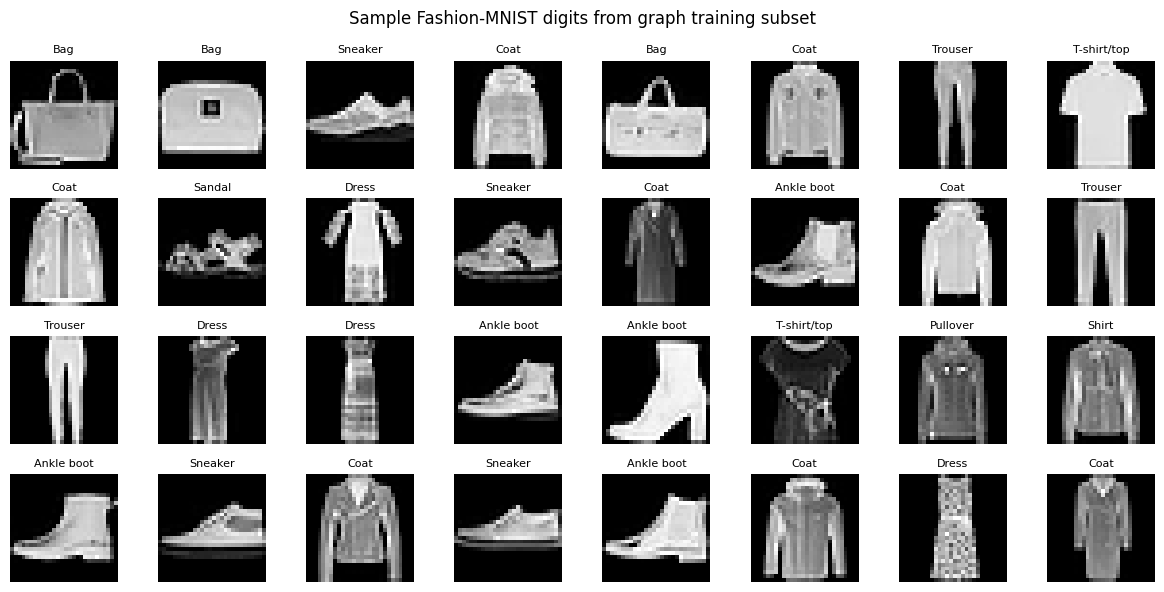

In [3]:
rng = np.random.RandomState(42)

N_TRAIN_GRAPH = 6000   # slightly larger than before; still safe with k-NN
N_TEST_EVAL = 2000

idx_train = rng.choice(X_train.shape[0], N_TRAIN_GRAPH, replace=False)
idx_test = rng.choice(X_test.shape[0], N_TEST_EVAL, replace=False)

X_graph = X_train[idx_train]
y_graph_true = y_train[idx_train]

X_test_eval = X_test[idx_test]
y_test_eval = y_test[idx_test]

print("Graph training set:", X_graph.shape, y_graph_true.shape)
print("Evaluation test set:", X_test_eval.shape, y_test_eval.shape)

# Visual sanity check: a few Fashion-MNIST examples
plot_digits_grid(
    X_graph[:32].reshape(-1, 28, 28),
    y_graph_true[:32],
    class_names=FASHION_MNIST_CLASSES,
    title="Sample Fashion-MNIST digits from graph training subset",
)



 ## 4. Construct a semi-supervised labeling



 Semi-supervised learning assumes that:



 - We only have labels for a **small subset** of points.

 - The remaining points are unlabeled but still helpful, because their

   position in feature space carries information about the underlying

   structure of the classes.



 We simulate this by:



 1. Choosing a fixed number of labeled examples per class,

    controlled by `N_LABELED_PER_CLASS`.

 2. Setting all remaining labels to `-1` to mark them as unlabeled.



 The helper function `make_semi_supervised_labels` (from

 `rice_ml.semi_supervised.utils`) encapsulates this logic.

Total graph points        : 6000
Labeled points (per class): 100
Unlabeled points          : 5900


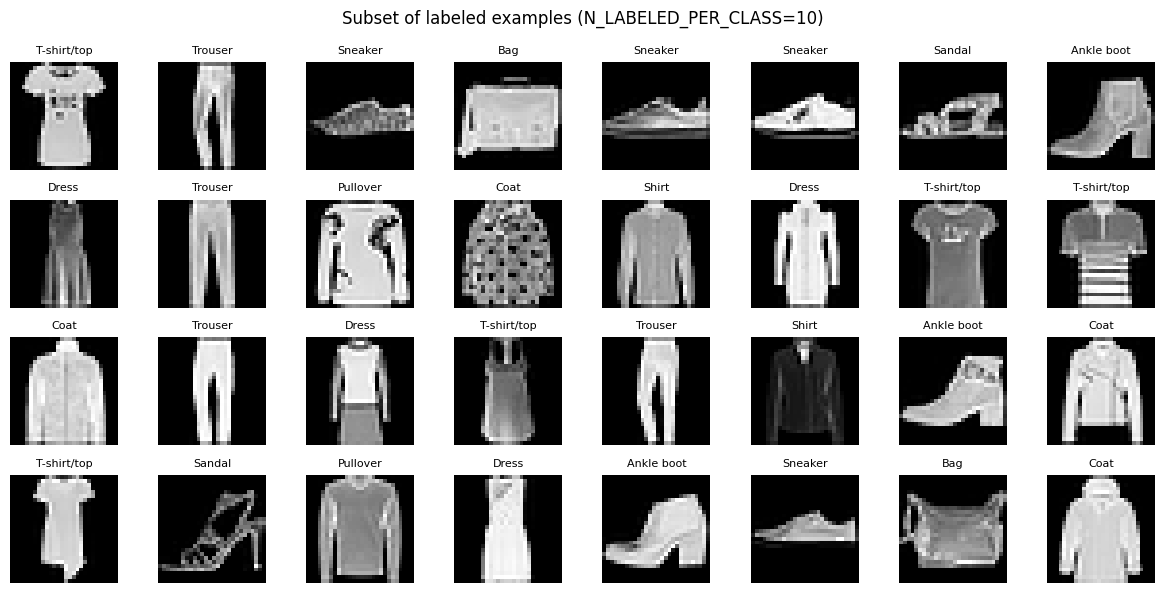

In [4]:
N_LABELED_PER_CLASS = 10  # e.g., at most 100 labeled points total

y_graph_semi, mask_labeled, mask_unlabeled = make_semi_supervised_labels(
    y_graph_true,
    n_labeled_per_class=N_LABELED_PER_CLASS,
    random_state=42,
)

print(f"Total graph points        : {len(y_graph_true)}")
print(f"Labeled points (per class): {mask_labeled.sum()}")
print(f"Unlabeled points          : {mask_unlabeled.sum()}")

plot_digits_grid(
    X_graph[mask_labeled][:32].reshape(-1, 28, 28),
    y_graph_true[mask_labeled][:32],
    class_names=FASHION_MNIST_CLASSES,
    title=f"Subset of labeled examples (N_LABELED_PER_CLASS={N_LABELED_PER_CLASS})",
)



 ## 5. Train the Label Propagation model



 We now instantiate and fit our custom `LabelPropagation` model from

 `rice_ml.semi_supervised.label_propagation`. Key hyperparameters:



 - `n_neighbors`: number of neighbors for the k-NN graph.

 - `gamma`: RBF width parameter; if `None`, a global scale is estimated

   from neighbor distances.

 - `alpha`: clamping factor; values close to 1 put more weight on

   propagated labels, while lower values keep labels closer to their

   initial values.



 The model stores timing information in `model.timing_` so we can

 inspect how long graph construction and propagation take.

In [5]:
LP_N_NEIGHBORS = 10
LP_ALPHA = 0.99
LP_GAMMA = None  # let the model estimate an appropriate sigma^2 automatically

lp = LabelPropagation(
    n_neighbors=LP_N_NEIGHBORS,
    alpha=LP_ALPHA,
    gamma=LP_GAMMA,
    max_iter=300,
    tol=1e-4,
    verbose=True,
)

with time_block("LabelPropagation.fit", store=lp.timing_):
    lp.fit(X_graph, y_graph_semi)

print("\nModel convergence info:")
print("  Converged:", lp.converged_)
print("  Iterations:", lp.n_iter_)
print("  Timing (seconds):", lp.timing_)



[LP] Building sparse k-NN graph (k=10)...
[LP] Starting propagation...
  iter 000, delta=10.246544
  iter 001, delta=2.419596
  iter 002, delta=0.743638
  iter 003, delta=0.319155
  iter 004, delta=0.188861
  iter 005, delta=0.130814
  iter 006, delta=0.098287
  iter 007, delta=0.077778
  iter 008, delta=0.063893
  iter 009, delta=0.053957
  iter 010, delta=0.046522
  iter 011, delta=0.040740
  iter 012, delta=0.036104
  iter 013, delta=0.032292
  iter 014, delta=0.029099
  iter 015, delta=0.026385
  iter 016, delta=0.024050
  iter 017, delta=0.022024
  iter 018, delta=0.020254
  iter 019, delta=0.018697
  iter 020, delta=0.017320
  iter 021, delta=0.016096
  iter 022, delta=0.015004
  iter 023, delta=0.014025
  iter 024, delta=0.013144
  iter 025, delta=0.012348
  iter 026, delta=0.011626
  iter 027, delta=0.010968
  iter 028, delta=0.010367
  iter 029, delta=0.009816
  iter 030, delta=0.009310
  iter 031, delta=0.008842
  iter 032, delta=0.008410
  iter 033, delta=0.008009
  iter 034

 ## 6. Evaluation: transductive and inductive performance



 We evaluate the model in two ways:



 1. **Transductive**: predictions on the graph training set used during fit.

    - Accuracy on **all** graph points (labeled + unlabeled).

    - Accuracy on labeled points only.

    - Accuracy on unlabeled points only.



 2. **Inductive**: predictions on the held-out test subset `X_test_eval`.

    Our implementation uses a soft k-NN rule in the original feature space

    to obtain class probabilities for new points and then takes the argmax.

In [6]:
# Transductive predictions (on the graph)
y_graph_pred = lp.predict()

acc_all = accuracy_score(y_graph_true, y_graph_pred)
acc_lab = accuracy_score(y_graph_true[mask_labeled], y_graph_pred[mask_labeled])
acc_unlab = accuracy_score(y_graph_true[mask_unlabeled], y_graph_pred[mask_unlabeled])

print("=== Label Propagation — Transductive Performance ===")
print(f"Accuracy on ALL graph points      : {acc_all:.4f}")
print(f"Accuracy on LABELED graph points  : {acc_lab:.4f}")
print(f"Accuracy on UNLABELED graph points: {acc_unlab:.4f}")

# Inductive predictions (on held-out test subset)
y_test_pred = lp.predict(X_test_eval)
acc_test = accuracy_score(y_test_eval, y_test_pred)

print("\n=== Label Propagation — Inductive Performance ===")
print(f"Test accuracy on {len(y_test_eval)} samples: {acc_test:.4f}")



=== Label Propagation — Transductive Performance ===
Accuracy on ALL graph points      : 0.5473
Accuracy on LABELED graph points  : 0.9500
Accuracy on UNLABELED graph points: 0.5405

=== Label Propagation — Inductive Performance ===
Test accuracy on 2000 samples: 0.5245


 ### 6.1 Confusion matrices and detailed report



 To better understand which classes are harder for the model, we plot

 confusion matrices and show a detailed classification report with per-class

 precision, recall, and F1 scores. Importantly, we use **Fashion-MNIST

 class names** instead of raw digit IDs.

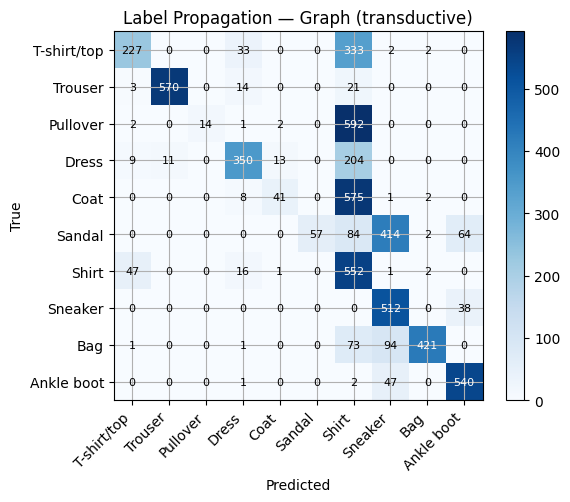

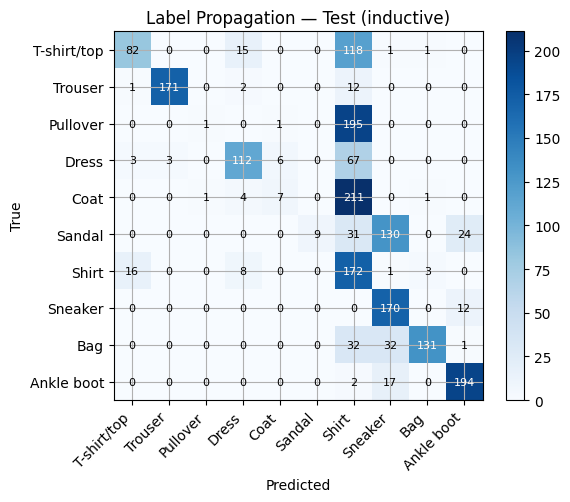

=== Classification report — Label Propagation (Test subset) ===
              precision    recall  f1-score   support

 T-shirt/top      0.804     0.378     0.514       217
     Trouser      0.983     0.919     0.950       186
    Pullover      0.500     0.005     0.010       197
       Dress      0.794     0.586     0.675       191
        Coat      0.500     0.031     0.059       224
      Sandal      1.000     0.046     0.089       194
       Shirt      0.205     0.860     0.331       200
     Sneaker      0.484     0.934     0.638       182
         Bag      0.963     0.668     0.789       196
  Ankle boot      0.840     0.911     0.874       213

    accuracy                          0.524      2000
   macro avg      0.707     0.534     0.493      2000
weighted avg      0.705     0.524     0.486      2000



In [7]:
classes = np.arange(10)

cm_graph = confusion_matrix(y_graph_true, y_graph_pred, labels=classes)
cm_test = confusion_matrix(y_test_eval, y_test_pred, labels=classes)

plot_confusion_matrix(
    cm_graph, classes=classes, class_names=FASHION_MNIST_CLASSES,
    title="Label Propagation — Graph (transductive)",
)
plot_confusion_matrix(
    cm_test, classes=classes, class_names=FASHION_MNIST_CLASSES,
    title="Label Propagation — Test (inductive)",
)

print("=== Classification report — Label Propagation (Test subset) ===")
print(classification_report(
    y_test_eval,
    y_test_pred,
    target_names=[FASHION_MNIST_CLASSES[c] for c in classes],
    digits=3,
))



 ### 6.2 Correct vs misclassified examples



 Looking at aggregated metrics is helpful, but concrete examples give more

 intuition. Below we show:



 - A few correctly classified test images.

 - A few misclassified images, with both the true and predicted class names.

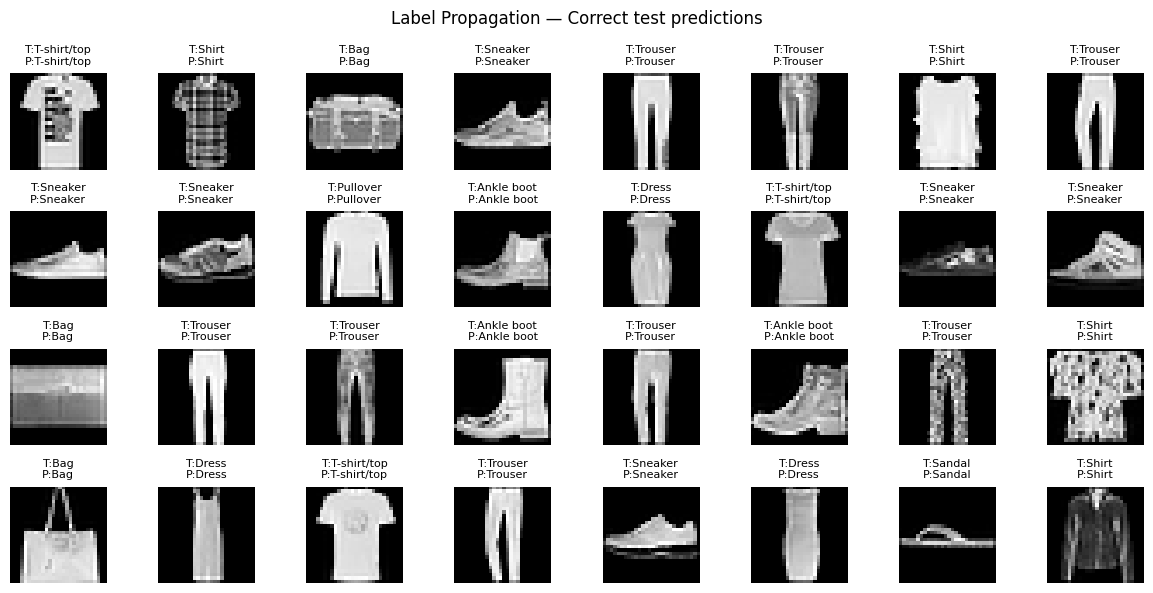

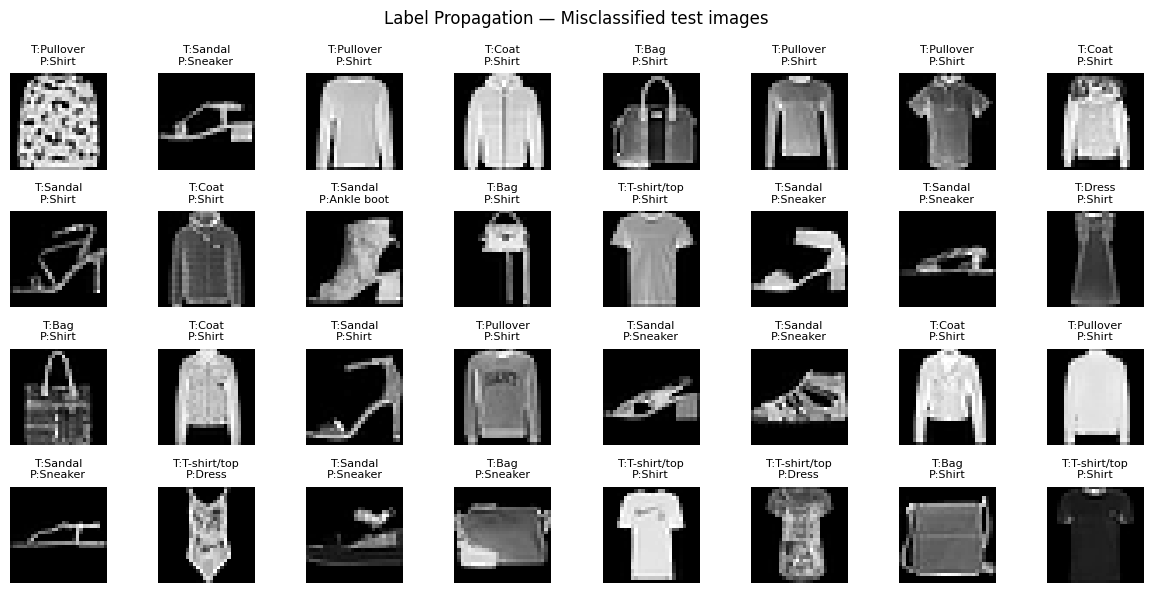

In [8]:
correct_idx = np.where(y_test_pred == y_test_eval)[0]
incorrect_idx = np.where(y_test_pred != y_test_eval)[0]

plot_digits_grid(
    X_test_eval[correct_idx][:32].reshape(-1, 28, 28),
    y_test_eval[correct_idx][:32],
    y_pred=y_test_pred[correct_idx][:32],
    class_names=FASHION_MNIST_CLASSES,
    title="Label Propagation — Correct test predictions",
)

plot_digits_grid(
    X_test_eval[incorrect_idx][:32].reshape(-1, 28, 28),
    y_test_eval[incorrect_idx][:32],
    y_pred=y_test_pred[incorrect_idx][:32],
    class_names=FASHION_MNIST_CLASSES,
    title="Label Propagation — Misclassified test images",
)



 ## 7. Supervised baseline: Logistic Regression



 To quantify the value of unlabeled data, we compare label propagation

 against a **purely supervised** baseline that only uses the labeled subset.



 Here we use multinomial logistic regression:



 - Train on `X_graph[mask_labeled]` and `y_graph_true[mask_labeled]`.

 - Evaluate on the same held-out test subset `X_test_eval`.

Supervised training data (labeled only): (100, 784) (100,)


c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Timing] LogisticRegression.fit: 2.503 s

=== Logistic Regression baseline ===
Test accuracy using ONLY labeled data: 0.6900


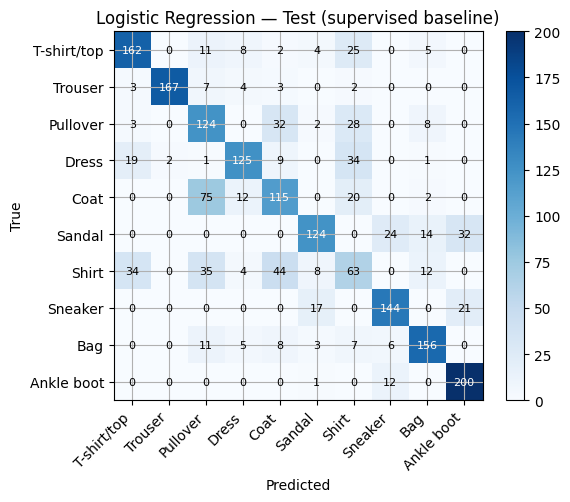

=== Classification report — Logistic Regression (Test subset) ===
              precision    recall  f1-score   support

 T-shirt/top      0.733     0.747     0.740       217
     Trouser      0.988     0.898     0.941       186
    Pullover      0.470     0.629     0.538       197
       Dress      0.791     0.654     0.716       191
        Coat      0.540     0.513     0.526       224
      Sandal      0.780     0.639     0.703       194
       Shirt      0.352     0.315     0.332       200
     Sneaker      0.774     0.791     0.783       182
         Bag      0.788     0.796     0.792       196
  Ankle boot      0.791     0.939     0.858       213

    accuracy                          0.690      2000
   macro avg      0.701     0.692     0.693      2000
weighted avg      0.696     0.690     0.690      2000



In [9]:
X_lab = X_graph[mask_labeled]
y_lab = y_graph_true[mask_labeled]

print("Supervised training data (labeled only):", X_lab.shape, y_lab.shape)

lr = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    n_jobs=-1,
)
with time_block("LogisticRegression.fit"):
    lr.fit(X_lab, y_lab)

y_test_lr = lr.predict(X_test_eval)
acc_lr = accuracy_score(y_test_eval, y_test_lr)

print("\n=== Logistic Regression baseline ===")
print(f"Test accuracy using ONLY labeled data: {acc_lr:.4f}")

cm_test_lr = confusion_matrix(y_test_eval, y_test_lr, labels=classes)
plot_confusion_matrix(
    cm_test_lr,
    classes=classes,
    class_names=FASHION_MNIST_CLASSES,
    title="Logistic Regression — Test (supervised baseline)",
)

print("=== Classification report — Logistic Regression (Test subset) ===")
print(classification_report(
    y_test_eval,
    y_test_lr,
    target_names=[FASHION_MNIST_CLASSES[c] for c in classes],
    digits=3,
))



 ## 8. Effect of the number of labeled samples



 A key question in semi-supervised learning is:



 > *How does performance change as we vary the amount of labeled data?*



 To study this, we:



 - Fix the graph training set (`X_graph`, `y_graph_true`).

 - For different values of `n_labeled_per_class`, we:

   1. Build a new semi-supervised label vector.

   2. Train label propagation.

   3. Train logistic regression on the labeled subset only.

   4. Evaluate both models on the same test subset.



 We then plot test accuracy vs. number of labeled examples per class.


[Effect of labels] n_labeled_per_class = 2


c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Effect of labels] n_labeled_per_class = 5


c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Effect of labels] n_labeled_per_class = 10


c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Effect of labels] n_labeled_per_class = 20


c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Effect of labels] n_labeled_per_class = 50


c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


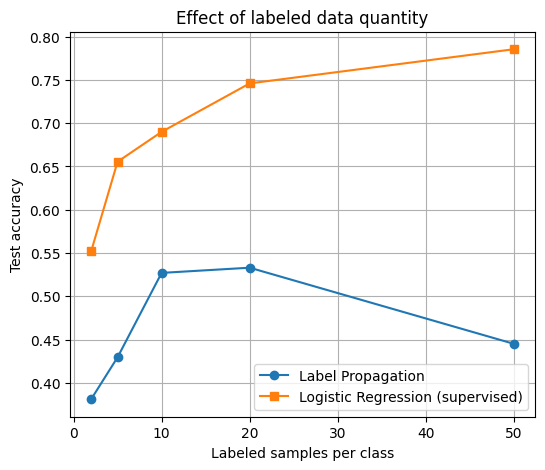

In [10]:
label_counts = [2, 5, 10, 20, 50]
lp_acc = []
lr_acc = []

for k in label_counts:
    print(f"\n[Effect of labels] n_labeled_per_class = {k}")

    y_semi_k, mask_l_k, _ = make_semi_supervised_labels(
        y_graph_true,
        n_labeled_per_class=k,
        random_state=42,
    )

    # Label Propagation
    lp_k = LabelPropagation(
        n_neighbors=LP_N_NEIGHBORS,
        alpha=LP_ALPHA,
        gamma=LP_GAMMA,
        max_iter=200,
        tol=1e-4,
        verbose=False,
    )
    lp_k.fit(X_graph, y_semi_k)
    y_test_lp_k = lp_k.predict(X_test_eval)
    lp_acc.append(accuracy_score(y_test_eval, y_test_lp_k))

    # Logistic Regression baseline (supervised only)
    X_lab_k = X_graph[mask_l_k]
    y_lab_k = y_graph_true[mask_l_k]

    lr_k = LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        n_jobs=-1,
    )
    lr_k.fit(X_lab_k, y_lab_k)
    y_test_lr_k = lr_k.predict(X_test_eval)
    lr_acc.append(accuracy_score(y_test_eval, y_test_lr_k))

plt.figure()
plt.plot(label_counts, lp_acc, marker="o", label="Label Propagation")
plt.plot(label_counts, lr_acc, marker="s", label="Logistic Regression (supervised)")
plt.xlabel("Labeled samples per class")
plt.ylabel("Test accuracy")
plt.title("Effect of labeled data quantity")
plt.legend()
plt.grid(True)
plt.show()



 ## 9. Hyperparameter study: n_neighbors, alpha, gamma



 Finally, we perform a small grid search over the main hyperparameters of

 the label propagation algorithm:



 - `n_neighbors`: neighborhood size in the k-NN graph.

 - `alpha`: clamping factor.

 - `gamma`: RBF kernel width (or `None` for automatic scale).



 For each combination, we:



 - Re-create the semi-supervised labeling with the same

   `N_LABELED_PER_CLASS`.

 - Fit a new `LabelPropagation` model.

 - Record test accuracy and some timing information.



 We then summarize results in a table and a simple heatmap.

[GridSearch] Combo 1/12: n_neighbors=5, alpha=0.9, gamma=None
[GridSearch] Combo 2/12: n_neighbors=5, alpha=0.9, gamma=0.01
[GridSearch] Combo 3/12: n_neighbors=5, alpha=0.99, gamma=None
[GridSearch] Combo 4/12: n_neighbors=5, alpha=0.99, gamma=0.01
[GridSearch] Combo 5/12: n_neighbors=10, alpha=0.9, gamma=None
[GridSearch] Combo 6/12: n_neighbors=10, alpha=0.9, gamma=0.01
[GridSearch] Combo 7/12: n_neighbors=10, alpha=0.99, gamma=None
[GridSearch] Combo 8/12: n_neighbors=10, alpha=0.99, gamma=0.01
[GridSearch] Combo 9/12: n_neighbors=15, alpha=0.9, gamma=None
[GridSearch] Combo 10/12: n_neighbors=15, alpha=0.9, gamma=0.01
[GridSearch] Combo 11/12: n_neighbors=15, alpha=0.99, gamma=None
[GridSearch] Combo 12/12: n_neighbors=15, alpha=0.99, gamma=0.01


,n_neighbors,alpha,gamma,test_acc,converged,n_iter,graph_build,propagation,fit_total,n_labeled,n_unlabeled,n_train
4,10,0.90,NaN,0.6690,True,43,0.574413,0.030259,0.608464,100,5900,6000
5,10,0.90,0.01,0.6670,True,42,0.555651,0.031015,0.590666,100,5900,6000
8,15,0.90,NaN,0.6585,True,42,0.630727,0.036850,0.670926,100,5900,6000
9,15,0.90,0.01,0.6585,True,42,0.620219,0.045481,0.669241,100,5900,6000
1,5,0.90,0.01,0.6470,True,48,0.573139,0.020499,0.596919,100,5900,6000
0,5,0.90,NaN,0.6470,True,48,0.527083,0.020065,0.550343,100,5900,6000
2,5,0.99,NaN,0.5850,False,200,0.573994,0.099027,0.676470,100,5900,6000
3,5,0.99,0.01,0.5825,False,200,0.581529,0.088774,0.673616,100,5900,6000
6,10,0.99,NaN,0.5270,False,200,0.584451,0.129164,0.717443,100,5900,6000
7,10,0.99,0.01,0.5245,False,200,0.600098,0.124635,0.728298,100,5900,6000


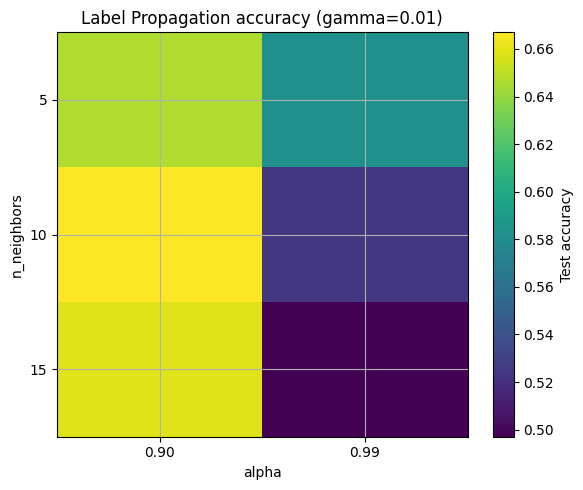

In [11]:
n_neighbors_grid = [5, 10, 15]
alpha_grid = [0.9, 0.99]
gamma_grid = [None, 0.01]  # None = automatic scale, 0.01 = fixed gamma

results_df = label_propagation_grid_search(
    X_graph=X_graph,
    y_graph_true=y_graph_true,
    X_test=X_test_eval,
    y_test=y_test_eval,
    n_labeled_per_class=N_LABELED_PER_CLASS,
    n_neighbors_list=n_neighbors_grid,
    alpha_list=alpha_grid,
    gamma_list=gamma_grid,
    max_iter=200,
    tol=1e-4,
    random_state=42,
    verbose=True,
)

display(results_df.sort_values(by="test_acc", ascending=False))


# Simple visualization: heatmap of test accuracy for each (n_neighbors, alpha)
# for gamma=None and gamma=0.01 separately.
for gamma_val in gamma_grid:
    subset = results_df[results_df["gamma"] == gamma_val]
    if subset.empty:
        continue

    pivot = subset.pivot_table(
        index="n_neighbors", columns="alpha", values="test_acc"
    )
    plt.figure()
    plt.imshow(pivot.values, cmap="viridis", aspect="auto")
    plt.colorbar(label="Test accuracy")
    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=[f"{a:.2f}" for a in pivot.columns],
    )
    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=[str(k) for k in pivot.index],
    )
    plt.xlabel("alpha")
    plt.ylabel("n_neighbors")
    plt.title(f"Label Propagation accuracy (gamma={gamma_val})")
    plt.tight_layout()
    plt.show()



 ## 10. PCA visualization of learned structure



 As a final qualitative check, we project the graph training data to 2D

 using PCA and color points by:



 - The **true** class labels.

 - The **propagated** (predicted) labels after label propagation.



 If the algorithm is working well, we should see coherent clusters where

 the predicted labels largely match the underlying true structure.

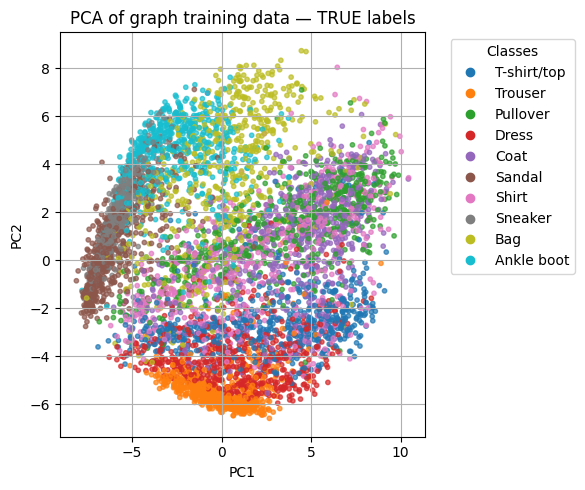

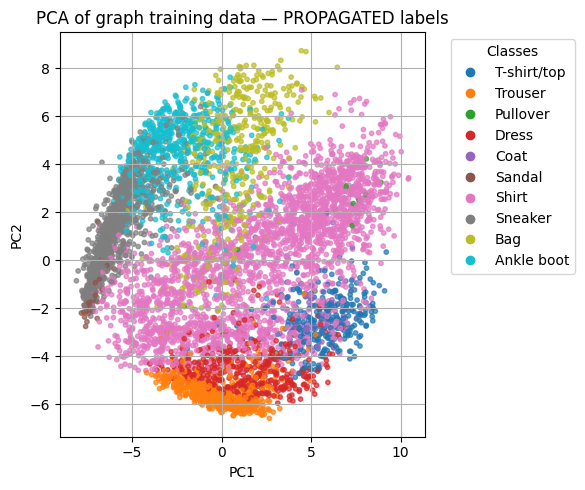

In [12]:
plot_pca_2d(
    X_graph,
    y_graph_true,
    class_names=FASHION_MNIST_CLASSES,
    title="PCA of graph training data — TRUE labels",
)

plot_pca_2d(
    X_graph,
    y_graph_pred,
    class_names=FASHION_MNIST_CLASSES,
    title="PCA of graph training data — PROPAGATED labels",
)
